In [2]:

# MPI-T8: Load CSV with pandas; print shape and dtypes


import pandas as pd

# Load dataset
df = pd.read_csv("C:/Users/ASUS/Downloads/HCL_Final/data/raw/MPIA_RAW_DATA.csv")

# Validate row and column count
print("Shape of dataset (rows, columns):", df.shape)

# Print column names
print("\nColumns in dataset:")
print(df.columns.tolist())

# Print data types
print("\nData types of each column:")
print(df.dtypes)

Shape of dataset (rows, columns): (331, 13)

Columns in dataset:
['employee_id', 'manager_id', 'manager_name', 'department', 'manager_experience', 'leadership_score', 'communication_score', 'manager_performance_score', 'employee_performance', 'satisfaction_score', 'attrition', 'project_success_score', 'revenue_generated']

Data types of each column:
employee_id                      str
manager_id                   float64
manager_name                     str
department                       str
manager_experience           float64
leadership_score             float64
communication_score          float64
manager_performance_score    float64
employee_performance         float64
satisfaction_score           float64
attrition                        str
project_success_score            str
revenue_generated                str
dtype: object


In [ ]:

# MPI-T9: Validate data types and convert as needed


# Fix revenue column (remove text and convert to numeric)
df['revenue_generated'] = df['revenue_generated'].astype(str).str.replace(' USD','')
df['revenue_generated'] = pd.to_numeric(df['revenue_generated'], errors='coerce')

# Convert project_success_score to numeric
df['project_success_score'] = pd.to_numeric(df['project_success_score'], errors='coerce')

# Clean IDs (remove spaces)
df['employee_id'] = df['employee_id'].str.strip()
df['manager_id'] = df['manager_id'].astype(str).str.strip()

# Check data types
print(df.dtypes)

employee_id                   object
manager_id                    object
manager_name                  object
department                    object
manager_experience           float64
leadership_score             float64
communication_score          float64
manager_performance_score    float64
employee_performance         float64
satisfaction_score           float64
attrition                     object
project_success_score        float64
revenue_generated            float64
dtype: object


In [ ]:

# MPI-T10: Check for duplicate rows and flag them


# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Show duplicate rows
print(df[df.duplicated()])

# Remove duplicates
df = df.drop_duplicates()

Duplicate Rows: 2
    employee_id manager_id   manager_name department  manager_experience  \
315         NaN        9.0   Vikas Yadav          IT                15.0   
322         NaN        1.0    Amit Sharma      Sales                10.0   

     leadership_score  communication_score  manager_performance_score  \
315              8.31                 8.03                       8.17   
322               NaN                 7.88                       7.47   

     employee_performance  satisfaction_score attrition  \
315                   NaN                9.75        No   
322                  8.11                 NaN       NaN   

     project_success_score  revenue_generated  
315                   8.53           90235.40  
322                  10.00           96887.59  


employee_id                  33
manager_id                    0
manager_name                 19
department                   25
manager_experience           25
leadership_score             26
communication_score          27
manager_performance_score    25
employee_performance         42
satisfaction_score           54
attrition                    18
project_success_score        52
revenue_generated            56
dtype: int64
employee_id                  10.030395
manager_id                    0.000000
manager_name                  5.775076
department                    7.598784
manager_experience            7.598784
leadership_score              7.902736
communication_score           8.206687
manager_performance_score     7.598784
employee_performance         12.765957
satisfaction_score           16.413374
attrition                     5.471125
project_success_score        15.805471
revenue_generated            17.021277
dtype: float64


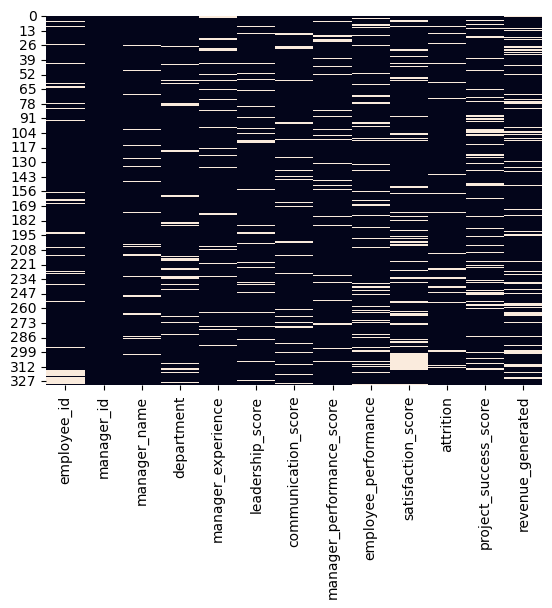

In [ ]:

# MPI-T11: Analyse missing values (count, % missing, pattern)


# Count missing values
print(df.isnull().sum())

# Percentage missing
print((df.isnull().sum() / len(df)) * 100)

# Simple pattern view
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.show()

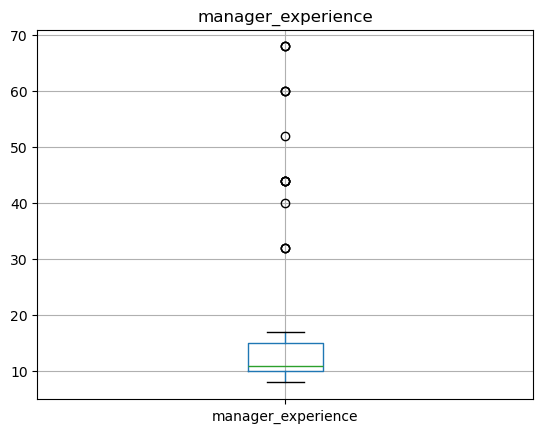

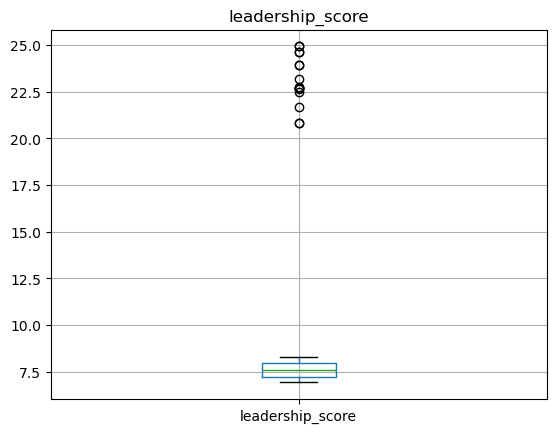

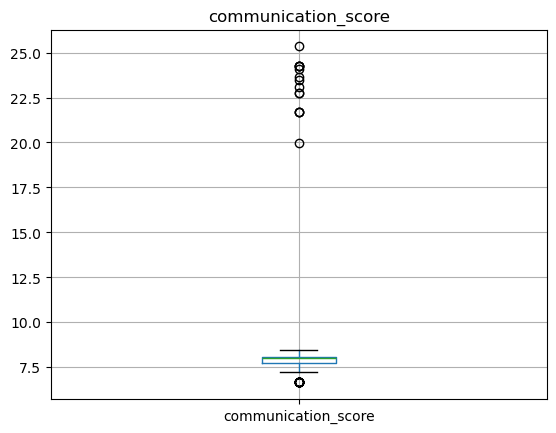

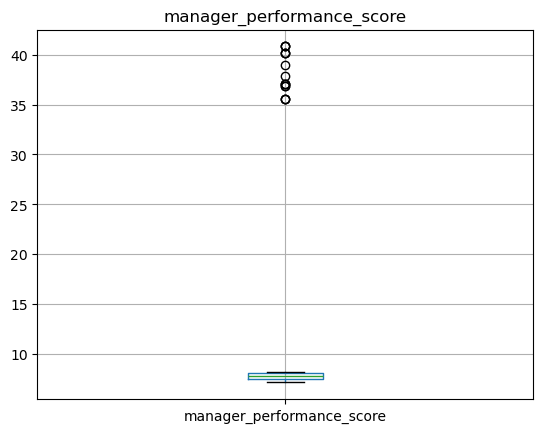

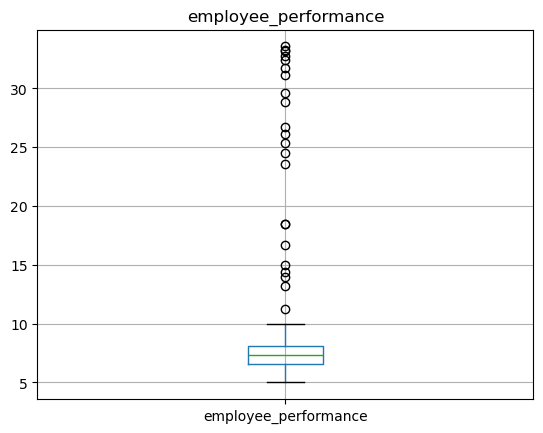

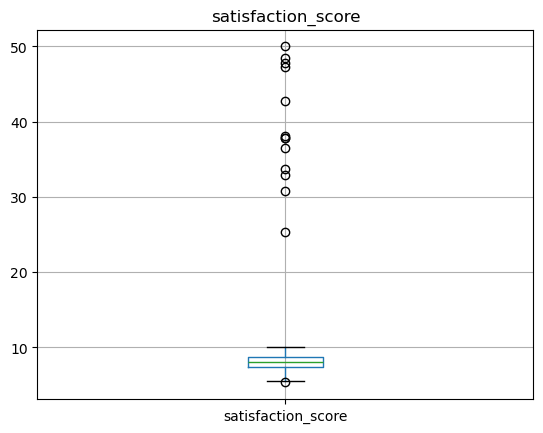

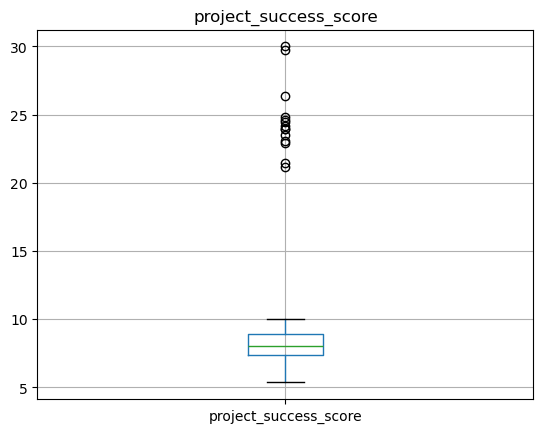

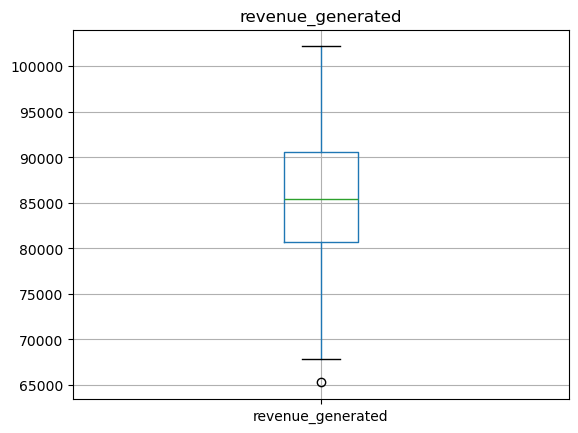

manager_experience outliers: 16
leadership_score outliers: 16
communication_score outliers: 34
manager_performance_score outliers: 16
employee_performance outliers: 22
satisfaction_score outliers: 14
project_success_score outliers: 14
revenue_generated outliers: 1


In [5]:

# MPI-T12: Check for outliers in numeric columns using IQR / boxplot


import matplotlib.pyplot as plt

# Select numeric columns
num_cols = df.select_dtypes(include='number').columns

# Boxplots
for col in num_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(col)
    plt.show()

# IQR method (count outliers)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(col, "outliers:", len(outliers))

In [6]:

# MPI-T13: Check category consistency


# Select categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Standardize values (lowercase + remove spaces)
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

# Check unique values
for col in cat_cols:
    print(col, ":", df[col].unique())

employee_id : ['emp_0001' 'emp_0002' 'emp_0003' 'emp_0004' 'emp_0005' nan 'emp_0007'
 'emp_0008' 'emp_0009' 'emp_0011' 'emp_0012' 'emp_0013' 'emp_0014'
 'emp_0015' 'emp_0016' 'emp_0017' 'emp_0018' 'emp_0019' 'emp_0020'
 'emp_0021' 'emp_0022' 'emp_0023' 'emp_0024' 'emp_0025' 'emp_0027'
 'emp_0028' 'emp_0029' 'emp_0030' 'emp_0031' 'emp_0032' 'emp_0033' 'nan'
 'emp_0035' 'emp_0036' 'emp_0037' 'emp_0038' 'emp_0039' 'emp_0040'
 'emp_0041' 'emp_0042' 'emp_0044' 'emp_0045' 'emp_0046' 'emp_0047'
 'emp_0048' 'emp_0049' 'emp_0050' 'emp_0051' 'emp_0052' 'emp_0053'
 'emp_0054' 'emp_0055' 'emp_0056' 'emp_0057' 'emp_0058' 'emp_0059'
 'emp_0060' 'emp_0062' 'emp_0063' 'emp_0065' 'emp_0066' 'emp_0067'
 'emp_0068' 'emp_0069' 'emp_0070' 'emp_0071' 'emp_0072' 'emp_0073'
 'emp_0074' 'emp_0075' 'emp_0076' 'emp_0077' 'emp_0078' 'emp_0080'
 'emp_0081' 'emp_0082' 'emp_0084' 'emp_0085' 'emp_0086' 'emp_0087'
 'emp_0088' 'emp_0089' 'emp_0090' 'emp_0091' 'emp_0092' 'emp_0093'
 'emp_0095' 'emp_0096' 'emp_0097' 'emp

In [7]:

# MPI-T14: Impute or drop missing values with documented strategy


# Drop columns with >40% missing
df = df.dropna(thresh=0.6*len(df), axis=1)

# Fill numeric columns with median
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:

# MPI-T15: Remove or cap outliers based on business context


# Cap numeric columns at 99th percentile
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)

In [9]:
df

,employee_id,manager_id,manager_name,department,manager_experience,leadership_score,communication_score,manager_performance_score,employee_performance,satisfaction_score,attrition,project_success_score,revenue_generated
0,emp_0001,1.0,amit sharma,sales,11.0,7.07,7.88,7.47,5.80,25.40,yes,6.21,85400.87
1,emp_0002,3.0,neha jain,sales,11.0,8.21,7.70,7.96,8.03,10.00,no,7.46,88426.79
2,emp_0003,3.0,neha jain,sales,9.0,8.21,7.70,7.96,7.32,9.32,no,6.52,86885.47
3,emp_0004,6.0,sneha kapoor,sales,8.0,7.98,8.08,8.03,7.62,8.21,no,8.49,83466.89
4,emp_0005,9.0,vikas yadav,it,15.0,8.31,8.03,8.17,8.65,8.01,no,8.03,83088.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...
326,nan,11.0,arjun nair,finance,10.0,7.58,8.08,7.66,6.41,8.78,no,7.83,79656.79
327,nan,4.0,priya verma,hr,17.0,7.50,8.07,7.79,6.70,7.30,no,7.80,85360.13
328,nan,11.0,arjun nair,sales,10.0,7.23,8.08,7.66,7.98,7.34,no,6.46,84033.01
329,nan,6.0,sneha kapoor,sales,8.0,7.98,8.03,8.03,8.87,8.63,no,9.42,93108.08


In [10]:

# MPI-T16: Encode categorical variables (without modifying original data)

# Create a separate copy for encoding (ML purpose)
df_ml = df.copy()

# Select categorical columns
cat_cols = df_ml.select_dtypes(include='object').columns

# Apply one-hot encoding
df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)

print("Encoded data shape:", df_ml.shape)

Encoded data shape: (329, 321)


In [11]:

# Save EDA-ready dataset 


df.to_csv("MPIA_EDA_READY.csv", index=False)

print("EDA-ready file saved!")

EDA-ready file saved!


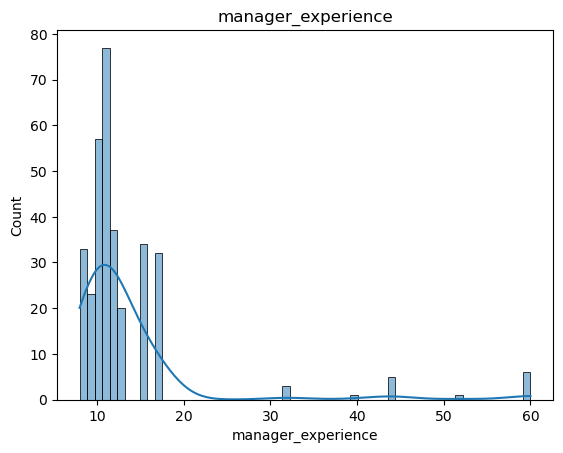

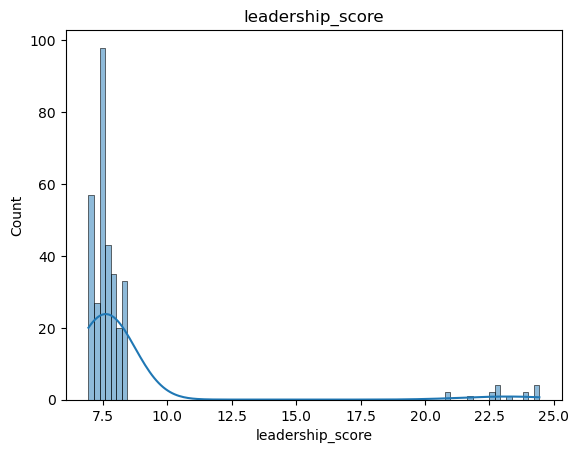

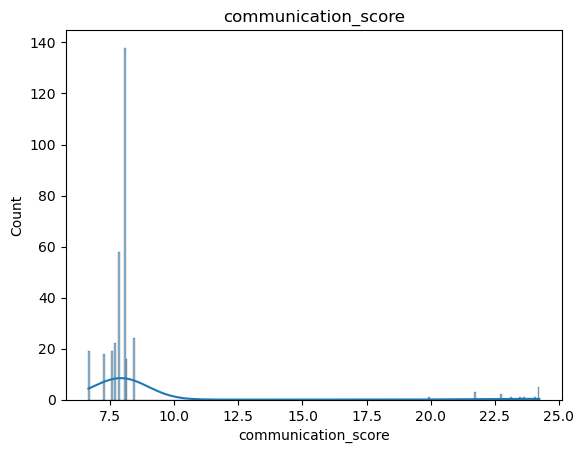

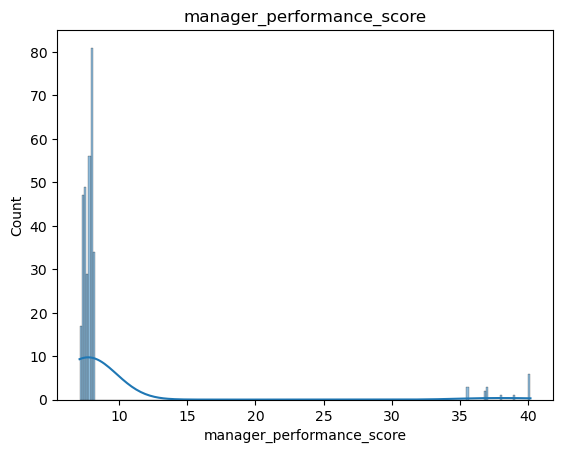

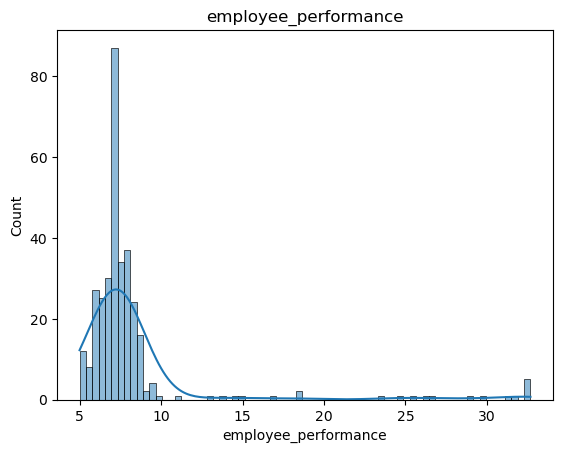

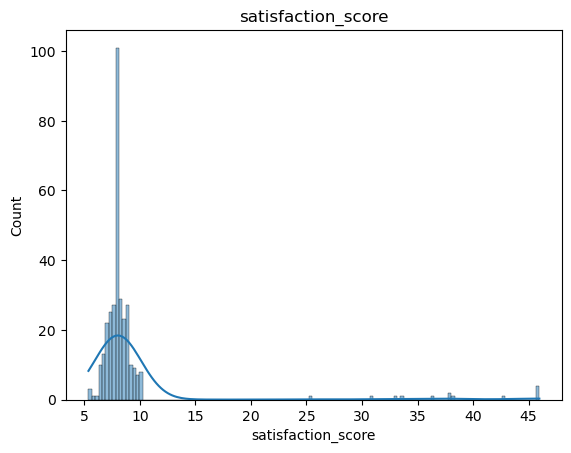

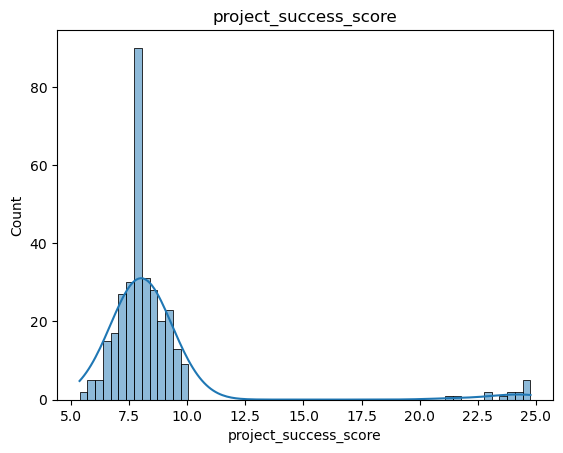

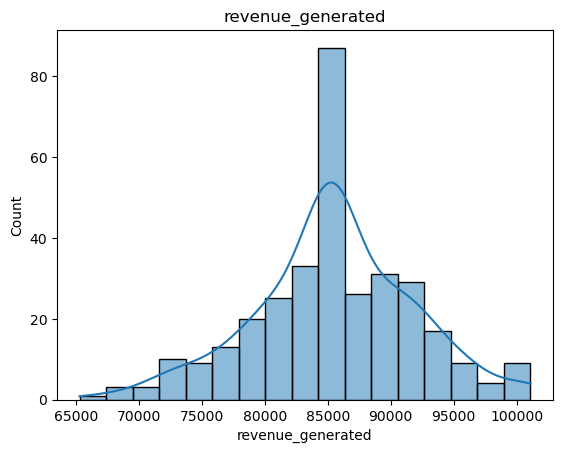

In [12]:

# MPI-T17: Plot distributions of numeric variables


import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
num_cols = df.select_dtypes(include='number').columns

# Plot histograms
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

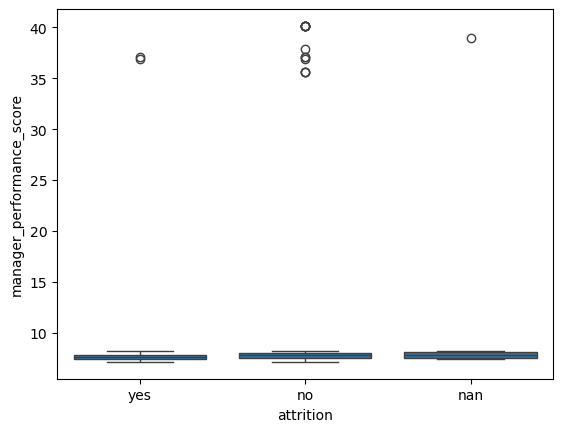

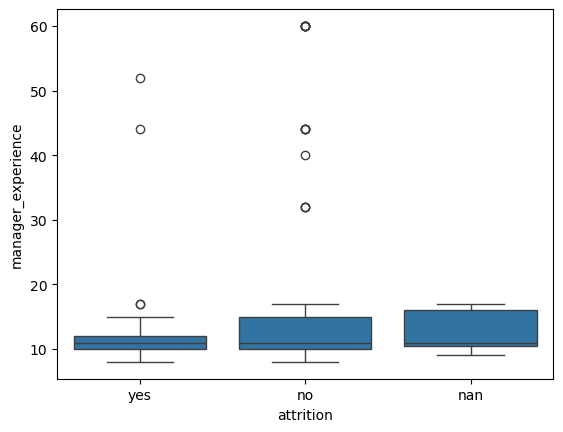

In [13]:

# MPI-T18: Analyse managerial features vs attrition


# Boxplot: manager performance vs attrition
sns.boxplot(x='attrition', y='manager_performance_score', data=df)
plt.show()

# Boxplot: experience vs attrition
sns.boxplot(x='attrition', y='manager_experience', data=df)
plt.show()

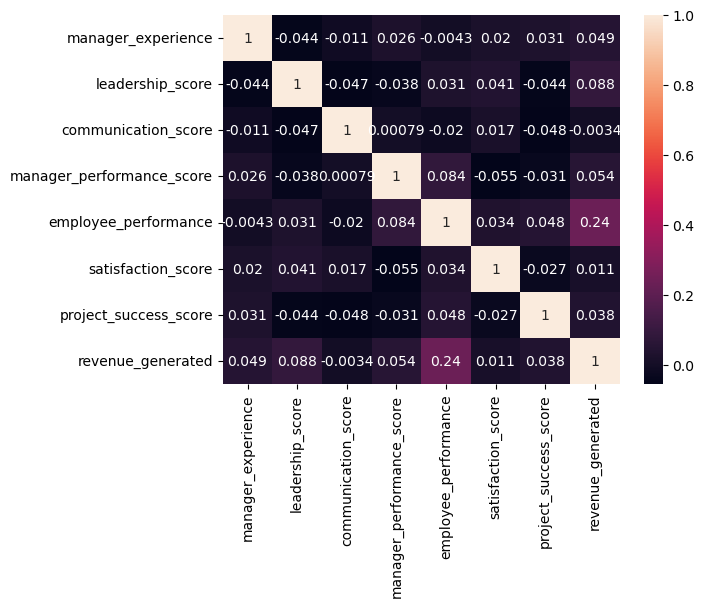

In [14]:

# MPI-T19: Correlation matrix (heatmap)

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True)
plt.show()

In [15]:

# MPI-T20: Group analysis (department & manager)


# Avg performance by department
print(df.groupby('department')['employee_performance'].mean())

# Avg performance by manager
print(df.groupby('manager_name')['employee_performance'].mean())

department
finance    7.912092
hr         8.479470
it         8.692593
nan        6.670000
sales      8.477316
Name: employee_performance, dtype: float64
manager_name
amit sharma       9.017200
anjali patel      9.329564
arjun nair        6.937241
karan mehta       7.503478
meera shah        9.635000
nan               7.100000
neha jain         7.537143
pooja malhotra    8.674520
priya verma       8.312105
rahul gupta       9.150000
rohit singh       7.854861
sneha kapoor      8.468571
vikas yadav       8.632941
Name: employee_performance, dtype: float64


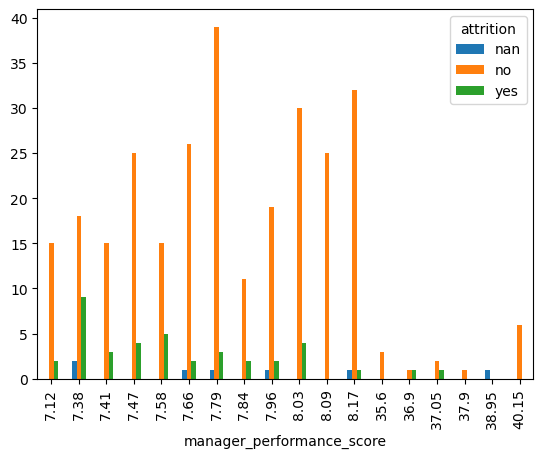

In [16]:
# ================================
# MPI-T21: Attrition by manager performance
# ================================

pivot = pd.pivot_table(
    df,
    values='employee_id',
    index='manager_performance_score',
    columns='attrition',
    aggfunc='count'
)

pivot.plot(kind='bar')
plt.show()

In [17]:
# ================================
# MPI-T22: Manager Effectiveness Score
# ================================

df['perf_norm'] = df['manager_performance_score'] / df['manager_performance_score'].max()
df['sat_norm'] = df['satisfaction_score'] / df['satisfaction_score'].max()

df['attrition_num'] = df['attrition'].map({'yes':1, 'no':0}).fillna(0)

df['manager_effectiveness_score'] = (
    0.4 * df['perf_norm'] +
    0.4 * df['sat_norm'] -
    0.2 * df['attrition_num']
)

# Show new column
df[['manager_performance_score','satisfaction_score','attrition','manager_effectiveness_score']].head()

,manager_performance_score,satisfaction_score,attrition,manager_effectiveness_score
0,7.47,25.40,yes,0.095444
1,7.96,10.00,no,0.166320
2,7.96,9.32,no,0.160403
3,8.03,8.21,no,0.151441
4,8.17,8.01,no,0.151095


In [18]:
# ================================
# MPI-T23: Team Productivity Index
# ================================

# Calculate team size (employees per manager)
team_size = df.groupby('manager_id')['employee_id'].count()

# Map team size to dataframe
df['team_size'] = df['manager_id'].map(team_size)

# Calculate productivity index
df['team_productivity_index'] = df['employee_performance'] / df['team_size']

# Handle division issues
df['team_productivity_index'] = df['team_productivity_index'].fillna(0)

# Show result
df[['manager_id','team_size','employee_performance','team_productivity_index']].head()

,manager_id,team_size,employee_performance,team_productivity_index
0,1.0,28,5.80,0.207143
1,3.0,22,8.03,0.365000
2,3.0,22,7.32,0.332727
3,6.0,36,7.62,0.211667
4,9.0,34,8.65,0.254412


In [19]:
# ================================
# MPI-T24: Tenure segments / experience bands
# ================================

bins = [5, 10, 15, 20, 50]
labels = ['5-10yr', '10-15yr', '15-20yr', '20+yr']

df['experience_band'] = pd.cut(df['manager_experience'], bins=bins, labels=labels)

df[['manager_experience','experience_band']]

,manager_experience,experience_band
0,11.0,10-15yr
1,11.0,10-15yr
2,9.0,5-10yr
3,8.0,5-10yr
4,15.0,10-15yr
...,...,...
326,10.0,5-10yr
327,17.0,15-20yr
328,10.0,5-10yr
329,8.0,5-10yr


In [20]:
# ================================
# MPI-T25: Normalize key features
# ================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ['manager_performance_score', 'employee_performance', 'revenue_generated']

df[cols] = scaler.fit_transform(df[cols])

# Show result
df[cols].head()

,manager_performance_score,employee_performance,revenue_generated
0,0.010596,0.028912,0.561612
1,0.025431,0.109503,0.646139
2,0.025431,0.083844,0.603083
3,0.027551,0.094686,0.507588
4,0.031789,0.131910,0.497019


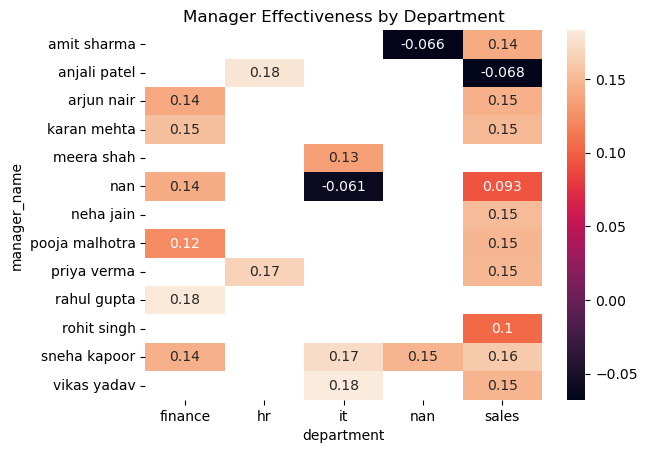

In [21]:
# ================================
# MPI-T26: Manager Effectiveness Heatmap
# ================================

pivot = df.pivot_table(
    values='manager_effectiveness_score',
    index='manager_name',
    columns='department',
    aggfunc='mean'
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pivot, annot=True)
plt.title("Manager Effectiveness by Department")
plt.show()

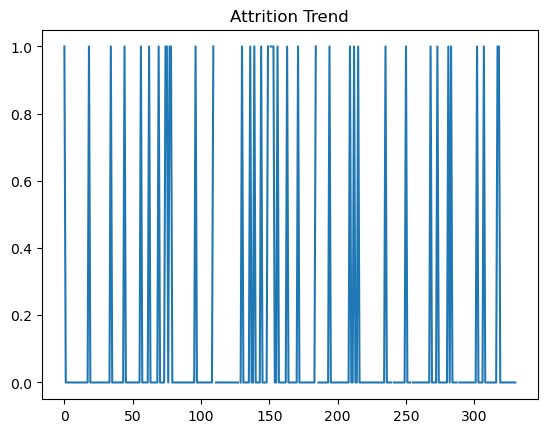

In [22]:
# ================================
# MPI-T27: Attrition trend
# ================================

df['attrition_num'] = df['attrition'].map({'yes':1, 'no':0})

df.groupby(df.index)['attrition_num'].mean().plot()
plt.title("Attrition Trend")
plt.show()

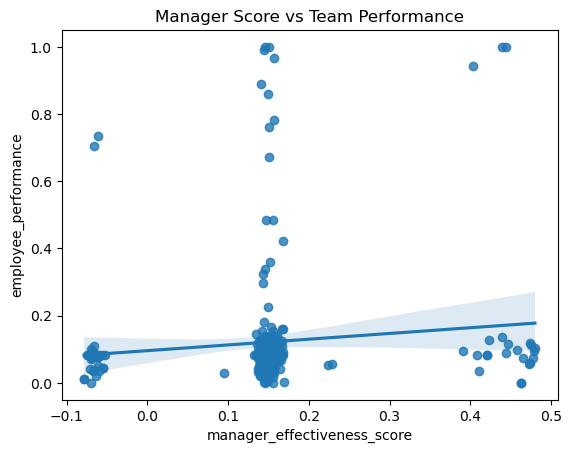

In [23]:
# ================================
# MPI-T28: Manager score vs team performance
# ================================

sns.regplot(
    x='manager_effectiveness_score',
    y='employee_performance',
    data=df
)

plt.title("Manager Score vs Team Performance")
plt.show()

In [24]:
# ================================
# MPI-T30: Summary statistics
# ================================

summary = df.describe()

print(summary)

# Save to Excel
summary.to_excel("summary_stats.xlsx")

       manager_experience  leadership_score  communication_score  \
count          329.000000        329.000000           329.000000   
mean            13.416413          8.361846             8.561125   
std              8.560037          3.351234             3.212914   
min              8.000000          6.940000             6.650000   
25%             10.000000          7.230000             7.830000   
50%             11.000000          7.580000             8.030000   
75%             13.000000          7.980000             8.080000   
max             60.000000         24.436800            24.240000   

       manager_performance_score  employee_performance  satisfaction_score  \
count                 329.000000            329.000000          329.000000   
mean                    0.063578              0.120908            9.222195   
std                     0.198505              0.171593            6.126098   
min                     0.000000              0.000000            5.370000 

In [25]:

# MPI-T31: Validate KPI formulas


df[['manager_performance_score','satisfaction_score','attrition','manager_effectiveness_score']].head(10)

,manager_performance_score,satisfaction_score,attrition,manager_effectiveness_score
0,0.010596,25.400,yes,0.095444
1,0.025431,10.000,no,0.166320
2,0.025431,9.320,no,0.160403
3,0.027551,8.210,no,0.151441
4,0.031789,8.010,no,0.151095
5,0.020285,8.010,no,0.147310
6,0.013927,45.968,no,0.475517
7,0.020285,8.910,no,0.155141
8,0.025431,37.800,no,0.408227
9,0.010596,8.010,no,0.144122
